In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, f1_score, multilabel_confusion_matrix

from sentence_transformers import SentenceTransformer

In [3]:
df = pd.read_csv("Data/Restaurant_ABSA_processed.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   review_en       800 non-null    object
 1   review_cleaned  800 non-null    object
 2   food            800 non-null    int64 
 3   price           800 non-null    int64 
 4   service         800 non-null    int64 
 5   ambiance        800 non-null    int64 
 6   miscellaneous   800 non-null    int64 
dtypes: int64(5), object(2)
memory usage: 43.9+ KB


In [4]:
aspect_cols = ['food', 'service', 'price', 'ambiance', 'miscellaneous']

X_text_cleaned = df['review_cleaned']
X_text = df['review_en']
y = df[aspect_cols].values

In [5]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text_cleaned, y, test_size=0.2, random_state=42
)
X_train_en, X_test_en, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42
)

In [6]:
sbert = SentenceTransformer('all-mpnet-base-v2')

X_train = sbert.encode(X_train_text.tolist(), show_progress_bar=True)
X_test = sbert.encode(X_test_text.tolist(), show_progress_bar=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

In [7]:
model_aspect = OneVsRestClassifier(
    LogisticRegression(
    max_iter=1000,
    C=1.0,
    class_weight='balanced'
)
)

model_aspect.fit(X_train, y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...max_iter=1000)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=

In [8]:
y_pred_prob = model_aspect.predict_proba(X_test)

In [9]:
thresholds = {}

for i, aspect in enumerate(aspect_cols):
    best_t = 0.5
    best_f1 = 0

    for t in np.arange(0.2, 0.9, 0.02):
        y_pred_temp = (y_pred_prob[:, i] >= t).astype(int)
        f1 = f1_score(y_test[:, i], y_pred_temp)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    thresholds[aspect] = round(best_t, 2)
    print(f"{aspect}: threshold={best_t:.2f}, F1={best_f1:.3f}")

food: threshold=0.42, F1=0.917
service: threshold=0.54, F1=0.887
price: threshold=0.46, F1=0.961
ambiance: threshold=0.52, F1=0.894
miscellaneous: threshold=0.54, F1=0.509


In [10]:
def apply_thresholds_advanced(y_prob, thresholds, top_k=2, remove_misc=True):
    """
    y_prob: (n_samples, n_aspects)
    thresholds: dict {aspect: threshold}
    top_k: giới hạn số aspect tối đa
    remove_misc: loại miscellaneous nếu có aspect khác
    """

    n_samples, n_aspects = y_prob.shape
    y_pred = np.zeros_like(y_prob)

    for i in range(n_samples):
        probs = y_prob[i]

        # ===== STEP 1: chọn theo threshold =====
        selected = [
            j for j in range(n_aspects)
            if probs[j] >= thresholds[aspect_cols[j]]
        ]

        # ===== STEP 2: fallback nếu không có =====
        if len(selected) == 0:
            selected = [np.argmax(probs)]

        # ===== STEP 3: loại miscellaneous nếu có class khác =====
        if remove_misc and len(selected) > top_k:
            selected = [
                j for j in selected
                if aspect_cols[j] != "miscellaneous"
            ]
            if len(selected) == 0:
                selected = [np.argmax(probs)]

        # ===== STEP 4: giới hạn top-k =====
        if len(selected) > top_k:
            selected = sorted(selected, key=lambda j: probs[j], reverse=True)[:top_k]

        # ===== STEP 5: gán nhãn =====
        for j in selected:
            y_pred[i, j] = 1

    return y_pred

y_pred_opt = apply_thresholds_advanced(
    y_pred_prob,
    thresholds,
    top_k=2,
    remove_misc=True
)

In [11]:
print(classification_report(y_test, y_pred_opt, target_names=aspect_cols))

print("F1 Micro:", f1_score(y_test, y_pred_opt, average='micro'))
print("F1 Macro:", f1_score(y_test, y_pred_opt, average='macro'))

               precision    recall  f1-score   support

         food       0.92      0.92      0.92       118
      service       0.88      0.90      0.89        48
        price       0.96      0.96      0.96        77
     ambiance       0.86      0.93      0.89        41
miscellaneous       0.87      0.43      0.58        30

    micro avg       0.91      0.88      0.89       314
    macro avg       0.90      0.83      0.85       314
 weighted avg       0.91      0.88      0.89       314
  samples avg       0.92      0.88      0.89       314

F1 Micro: 0.8946515397082658
F1 Macro: 0.8469573122616054


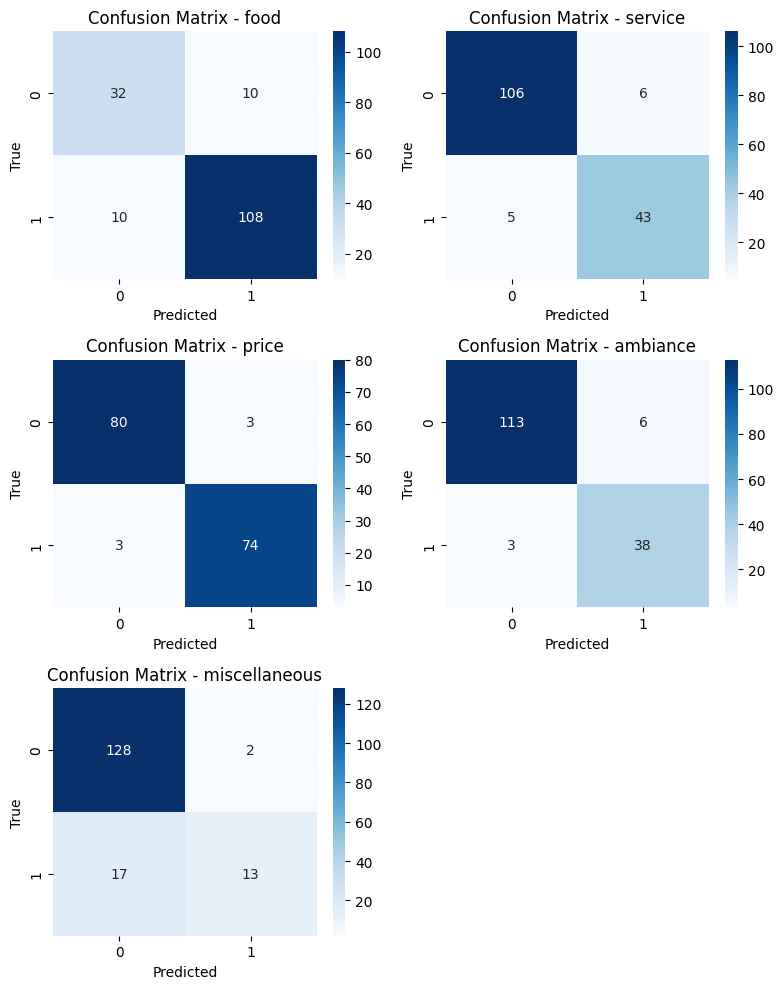

In [12]:
mcm = multilabel_confusion_matrix(y_test, y_pred_opt)
plt.figure(figsize=(8, 10))
for i, aspect in enumerate(aspect_cols):

    plt.subplot(3, 2, i + 1)

    sns.heatmap(
        mcm[i],
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {aspect}')
    plt.xlabel('Predicted')
    plt.ylabel('True')

plt.tight_layout()
plt.show()

In [13]:
# Step 1: Prepare new review text
new_reviews = [
    "I'll come again",
    "Great ambiance and reasonable prices"
]

# Step 2: Encode reviews using the same SentenceTransformer
X_new = sbert.encode(new_reviews, show_progress_bar=True)

# Step 3: Get probability predictions
y_pred_prob_new = model_aspect.predict_proba(X_new)

# Step 4: Apply optimized thresholds
y_pred_new = apply_thresholds_advanced(
    y_pred_prob_new,
    thresholds,
    top_k=2,
    remove_misc=True
)

# Step 5: Display results
for i, review in enumerate(new_reviews):
    predicted_aspects = [aspect_cols[j] for j in range(len(aspect_cols)) if y_pred_new[i, j] == 1]
    print(f"Review: {review}")
    print(f"Predicted Aspects: {predicted_aspects}\n")
    print(f"Probabilities: {dict(zip(aspect_cols, y_pred_prob_new[i].round(3)))}")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Review: I'll come again
Predicted Aspects: ['food', 'miscellaneous']

Probabilities: {'food': np.float64(0.697), 'service': np.float64(0.506), 'price': np.float64(0.16), 'ambiance': np.float64(0.326), 'miscellaneous': np.float64(0.659)}
Review: Great ambiance and reasonable prices
Predicted Aspects: ['price', 'ambiance']

Probabilities: {'food': np.float64(0.176), 'service': np.float64(0.243), 'price': np.float64(0.62), 'ambiance': np.float64(0.843), 'miscellaneous': np.float64(0.325)}


In [14]:
# Find samples where prediction differs from actual label
misclassified_indices = []

for i in range(len(y_test)):
    if not np.array_equal(y_pred_opt[i], y_test[i]):
        misclassified_indices.append(i)

print(f"Total misclassified samples: {len(misclassified_indices)} out of {len(y_test)}\n")

# Display details of wrong predictions
for idx in misclassified_indices[:10]:  # Show first 10 misclassified
    print(f"{'='*80}")
    print(f"Sample Index: {idx}")
    print(f"Review: {X_test_en.iloc[idx]}")
    print(f"Cleaned Review: {X_test_text.iloc[idx]}")
    print(f"\nTrue Labels: {[aspect_cols[j] for j in range(len(aspect_cols)) if y_test[idx, j] == 1]}")
    print(f"Predicted: {[aspect_cols[j] for j in range(len(aspect_cols)) if y_pred_opt[idx, j] == 1]}")
    print(f"Probabilities: {dict(zip(aspect_cols, y_pred_prob[idx].round(3)))}")
    print()

Total misclassified samples: 39 out of 160

Sample Index: 3
Review: From today it is my favorite restaurant because the service here is very bad and the price of everything is very high.
Cleaned Review: today favorite restaurant service bad price everything high

True Labels: ['service', 'price']
Predicted: ['food', 'price']
Probabilities: {'food': np.float64(0.422), 'service': np.float64(0.273), 'price': np.float64(0.872), 'ambiance': np.float64(0.2), 'miscellaneous': np.float64(0.277)}

Sample Index: 5
Review: If you want good coffee, you need a quiet environment.
Cleaned Review: want good coffee need quiet environment

True Labels: ['food', 'ambiance']
Predicted: ['ambiance']
Probabilities: {'food': np.float64(0.343), 'service': np.float64(0.206), 'price': np.float64(0.351), 'ambiance': np.float64(0.912), 'miscellaneous': np.float64(0.251)}

Sample Index: 11
Review: There is no extra decoration and the service is decent.
Cleaned Review: extra decoration service decent

True Labels: 